In [85]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack

In [4]:
wcr_data = pd.read_excel("C://python_projects//machine_learning//Capstone_NLP_Woman_Clothing_E-Commerce_Platform//Womens_Clothing_Reviews_Data.xlsx")

In [5]:
wcr_data

,Product ID,Category,Subcategory1,SubCategory2,Location,Channel,Customer Age,Review Title,Review Text,Rating,Recommend Flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1
...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1


In [8]:
wcr_data.columns = wcr_data.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
wcr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      23486 non-null  int64 
 1   category        23472 non-null  object
 2   subcategory1    23472 non-null  object
 3   subcategory2    23472 non-null  object
 4   location        23486 non-null  object
 5   channel         23486 non-null  object
 6   customer_age    23486 non-null  int64 
 7   review_title    19676 non-null  object
 8   review_text     22641 non-null  object
 9   rating          23486 non-null  int64 
 10  recommend_flag  23486 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 2.0+ MB


In [10]:
wcr_data.isna().sum()

product_id           0
category            14
subcategory1        14
subcategory2        14
location             0
channel              0
customer_age         0
review_title      3810
review_text        845
rating               0
recommend_flag       0
dtype: int64

In [11]:
wcr_data.describe()

,product_id,customer_age,rating,recommend_flag
count,23486.000000,23486.000000,23486.000000,23486.000000
mean,918.118709,43.198544,4.196032,0.822362
std,203.298980,12.279544,1.110031,0.382216
min,0.000000,18.000000,1.000000,0.000000
25%,861.000000,34.000000,4.000000,1.000000
50%,936.000000,41.000000,5.000000,1.000000
75%,1078.000000,52.000000,5.000000,1.000000
max,1205.000000,99.000000,5.000000,1.000000


In [12]:
df = wcr_data.copy()

In [13]:
df = df[df['review_text'].notna()]

In [14]:
df.shape

(22641, 11)

In [15]:
df['review_text'].str.strip().eq('').sum()

np.int64(0)

In [16]:
df

,product_id,category,subcategory1,subcategory2,location,channel,customer_age,review_title,review_text,rating,recommend_flag
0,767,Initmates,Intimate,Intimates,Mumbai,Mobile,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1
1,1080,General,Dresses,Dresses,Bangalore,Mobile,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1
2,1077,General,Dresses,Dresses,Gurgaon,Mobile,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0
3,1049,General Petite,Bottoms,Pants,Chennai,Web,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1
4,847,General,Tops,Blouses,Bangalore,Web,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1
...,...,...,...,...,...,...,...,...,...,...,...
23481,1104,General Petite,Dresses,Dresses,Gurgaon,Mobile,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1
23482,862,General Petite,Tops,Knits,Gurgaon,Web,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1
23483,1104,General Petite,Dresses,Dresses,Gurgaon,Web,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0
23484,1084,General,Dresses,Dresses,Gurgaon,Web,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1


In [17]:
df['review_length'] = df['review_text'].str.len()

In [18]:
df['review_length'].describe()

count    22641.000000
mean       309.542423
std        144.676295
min          9.000000
25%        187.000000
50%        302.000000
75%        460.000000
max        572.000000
Name: review_length, dtype: float64

In [19]:
df['review_text'].sample(5)

7753     I took a chance on this in green, extra small ...
22298    I liked the idea of the scarf tie, so i tried ...
6446     This sweater drapes beautifully, but beware it...
21282    I love the colors in this top, but sadly i'm g...
13324    If these jeans work for you, you're a lucky gi...
Name: review_text, dtype: object

In [20]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) 
    text = re.sub(r'[^a-z\s]', ' ', text)      
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [21]:
df['clean_review'] = df['review_text'].apply(clean_text)

In [22]:
df[['review_text', 'clean_review']].sample(5)

,review_text,clean_review
2356,Love this blouse! the color is really unique a...,love this blouse the color is really unique an...
23275,Love this top! off the shoulder fits great! li...,love this top off the shoulder fits great litt...
21688,I disagree with the most recent review! they a...,i disagree with the most recent review they ar...
1779,Gorgeous skirt. runs a bit big. well made. pe...,gorgeous skirt runs a bit big well made perfec...
18819,The neckline is beautiful! it's super soft and...,the neckline is beautiful it s super soft and ...


In [23]:
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return ' '.join(words)

In [24]:
df['clean_nostop'] = df['clean_review'].apply(remove_stopwords)

In [25]:
df[['clean_review', 'clean_nostop']].sample(5)

,clean_review,clean_nostop
1891,i purchased this and another eva franco dress ...,purchased eva franco dress retailer s recent s...
18756,this dress comes with a built in fupa literall...,dress comes built fupa literally extra materia...
10381,this sweater is gorgeous the color is a true p...,sweater gorgeous color true periwinkle really ...
1655,this runs really big i usually wear s or m so ...,runs really big usually wear s m got small nee...
19023,love these shorts not too tight and not too sh...,love shorts tight short match tops tts hard fi...


In [26]:
df['sentiment'] = np.where(df['rating'] >= 4, 'positive', 'negative')

In [27]:
positive_reviews = df[df['sentiment'] == 'positive']['clean_nostop']
negative_reviews = df[df['sentiment'] == 'negative']['clean_nostop']

In [28]:
positive_words = Counter(" ".join(positive_reviews).split()).most_common(20)
negative_words = Counter(" ".join(negative_reviews).split()).most_common(20)

In [29]:
positive_words

[('dress', 8038),
 ('love', 7742),
 ('s', 7088),
 ('size', 7081),
 ('t', 6279),
 ('fit', 5631),
 ('wear', 5422),
 ('great', 5417),
 ('m', 5305),
 ('like', 4929),
 ('just', 4011),
 ('color', 3634),
 ('small', 3531),
 ('perfect', 3517),
 ('fabric', 3272),
 ('d', 3261),
 ('little', 3247),
 ('flattering', 2953),
 ('soft', 2924),
 ('look', 2840)]

In [30]:
negative_words

[('t', 2578),
 ('dress', 2533),
 ('like', 2221),
 ('s', 1921),
 ('fit', 1695),
 ('size', 1693),
 ('just', 1597),
 ('fabric', 1526),
 ('m', 1415),
 ('love', 1209),
 ('look', 1200),
 ('small', 1198),
 ('really', 1120),
 ('d', 1093),
 ('ordered', 1089),
 ('wear', 1017),
 ('color', 971),
 ('material', 886),
 ('shirt', 864),
 ('x', 834)]

In [31]:
def remove_stopwords_and_short_tokens(text):
    words = text.split()
    words = [
        word for word in words
        if word not in ENGLISH_STOP_WORDS and len(word) > 1
    ]
    return ' '.join(words)

In [32]:
df['clean_nostop'] = df['clean_review'].apply(remove_stopwords_and_short_tokens)

In [33]:
positive_reviews = df[df['sentiment'] == 'positive']['clean_nostop']
negative_reviews = df[df['sentiment'] == 'negative']['clean_nostop']

In [34]:
positive_words = Counter(" ".join(positive_reviews).split()).most_common(20)
negative_words = Counter(" ".join(negative_reviews).split()).most_common(20)

In [35]:
positive_words

[('dress', 8038),
 ('love', 7742),
 ('size', 7081),
 ('fit', 5631),
 ('wear', 5422),
 ('great', 5417),
 ('like', 4929),
 ('just', 4011),
 ('color', 3634),
 ('small', 3531),
 ('perfect', 3517),
 ('fabric', 3272),
 ('little', 3247),
 ('flattering', 2953),
 ('soft', 2924),
 ('look', 2840),
 ('comfortable', 2829),
 ('really', 2810),
 ('ordered', 2761),
 ('fits', 2600)]

In [36]:
negative_words

[('dress', 2533),
 ('like', 2221),
 ('fit', 1695),
 ('size', 1693),
 ('just', 1597),
 ('fabric', 1526),
 ('love', 1209),
 ('look', 1200),
 ('small', 1198),
 ('really', 1120),
 ('ordered', 1089),
 ('wear', 1017),
 ('color', 971),
 ('material', 886),
 ('shirt', 864),
 ('way', 815),
 ('large', 768),
 ('looks', 743),
 ('cute', 737),
 ('didn', 701)]

In [37]:
df['clean_nostop'] = df['clean_nostop'].str.replace(r'\bdidn\b', '', regex=True)

In [38]:
df['clean_nostop'].sample(10)

7004     loved sweater wrap bought colors light weight ...
3008     just bought dress store absolutely love thing ...
2447     beautiful runs large exchanging size smaller w...
4576     love blouse soft nice drape voluminous true si...
4567     got shirt gift cute comfortable little need we...
2884     idea shirt awesome just needs longer boxy ruff...
11577    cute quirky feminine ruffle detailing polka do...
19317    photos dress justice loved soon tried good qua...
22321    truly gorgeous dress ran little small shoulder...
4302     thought dress looked really cute people gave g...
Name: clean_nostop, dtype: object

In [39]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


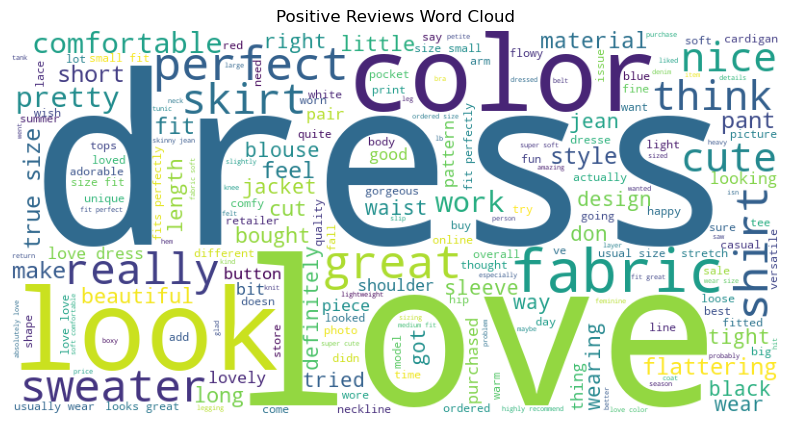

In [40]:
positive_text = " ".join(positive_reviews)
wc_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos)
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

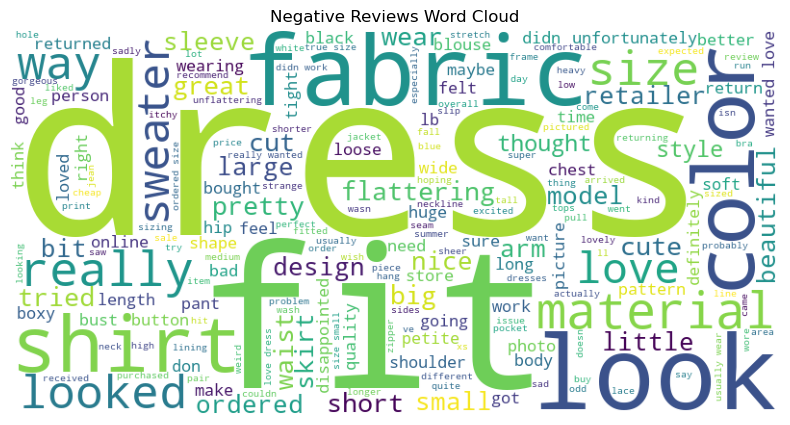

In [41]:
negative_text = " ".join(negative_reviews)
wc_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

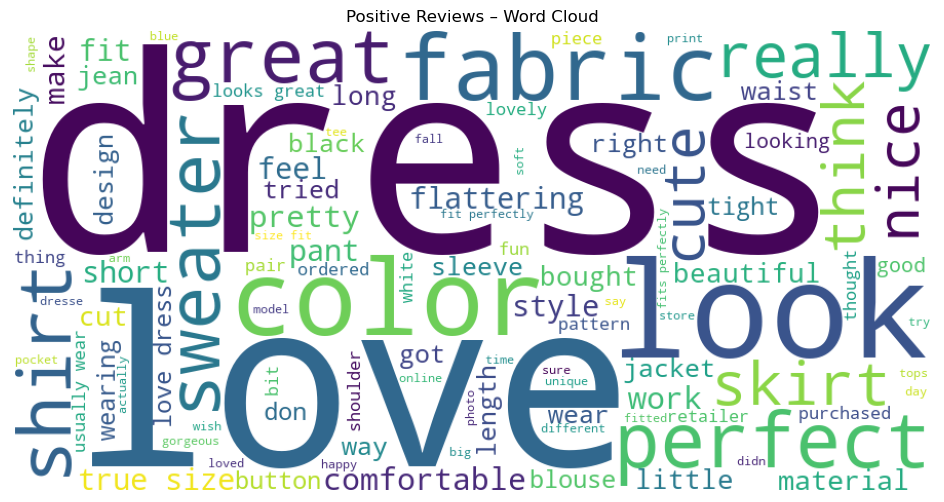

In [42]:
positive_text = " ".join(positive_reviews)
wc_pos = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=100
).generate(positive_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Positive Reviews – Word Cloud")
plt.show()

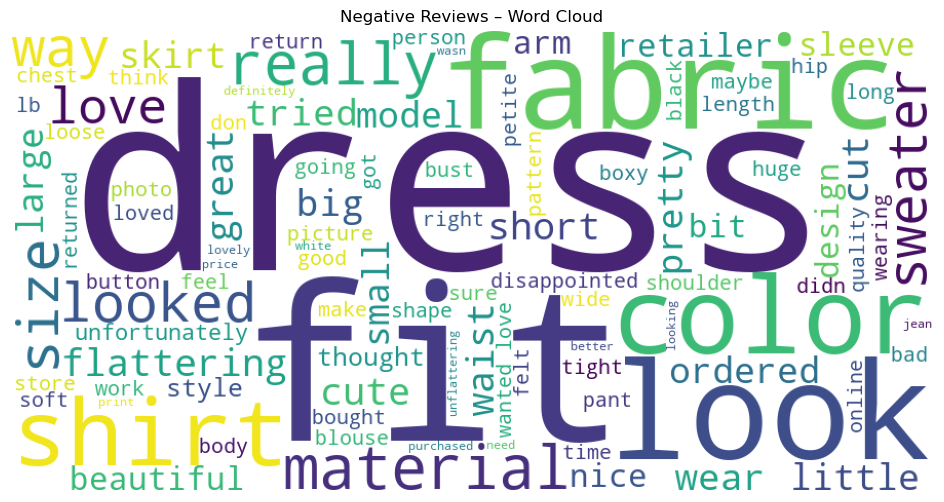

In [43]:
negative_text = " ".join(negative_reviews)
wc_neg = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=100
).generate(negative_text)
plt.figure(figsize=(12,6))
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Negative Reviews – Word Cloud")
plt.show()

In [44]:
text_data = df['clean_nostop']

In [45]:
df['clean_nostop'].head()

0          absolutely wonderful silky sexy comfortable
1    love dress soo pretty happened store glad did ...
2    high hopes dress really wanted work initially ...
3    love love love jumpsuit fun flirty fabulous ti...
4    shirt flattering adjustable tie perfect length...
Name: clean_nostop, dtype: object

In [46]:
vectorizer = CountVectorizer(
    max_df=0.95,  
    min_df=10      
)

In [47]:
doc_term_matrix = vectorizer.fit_transform(df['clean_nostop'])

In [48]:
doc_term_matrix.shape

(22641, 3059)

In [49]:
len(vectorizer.vocabulary_)

3059

In [57]:
lda_model = LatentDirichletAllocation(
    n_components= 5,
    random_state=42
)

In [58]:
lda_model.fit(doc_term_matrix)

LatentDirichletAllocation(n_components=5, random_state=42)

In [59]:
lda_model.components_.shape

(5, 3059)

In [61]:
try:
    feature_names = vectorizer.get_feature_names_out()
except:
    feature_names = vectorizer.get_feature_names()

In [62]:
len(feature_names)

3059

In [63]:
for idx, topic in enumerate(lda_model.components_):
    print(f"\nTopic {idx + 1}:")
    top_words = topic.argsort()[-10:][::-1]
    print([feature_names[i] for i in top_words])


Topic 1:
['color', 'shirt', 'white', 'love', 'like', 'blue', 'bought', 'black', 'looks', 'colors']

Topic 2:
['like', 'dress', 'fabric', 'just', 'look', 'really', 'fit', 'material', 'way', 'sweater']

Topic 3:
['dress', 'love', 'size', 'wear', 'beautiful', 'perfect', 'flattering', 'retailer', 'fits', 'fit']

Topic 4:
['size', 'small', 'fit', 'ordered', 'medium', 'large', 'petite', 'wear', 'xs', 'usually']

Topic 5:
['great', 'love', 'wear', 'perfect', 'soft', 'comfortable', 'jeans', 'sweater', 'nice', 'like']


In [64]:
y = df['recommend_flag']

In [65]:
X_text = df['clean_review']

In [67]:
tfidf = TfidfVectorizer(
    max_df=0.9,
    min_df=10,
    ngram_range=(1,2)
)

In [68]:
X = tfidf.fit_transform(X_text)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [73]:
model = LogisticRegression(max_iter=1000)

In [74]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [78]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 518  507]
 [ 137 4499]]
              precision    recall  f1-score   support

           0       0.79      0.51      0.62      1025
           1       0.90      0.97      0.93      4636

    accuracy                           0.89      5661
   macro avg       0.84      0.74      0.77      5661
weighted avg       0.88      0.89      0.88      5661



In [79]:
X_text = df['clean_review']

In [80]:
tfidf = TfidfVectorizer(
    max_df=0.9,
    min_df=10,
    ngram_range=(1,2)
)

In [81]:
X_text_tfidf = tfidf.fit_transform(X_text)

In [82]:
X_num = df[['rating', 'customer_age']]

In [84]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

In [86]:
X_final = hstack([X_text_tfidf, X_num_scaled])

In [87]:
y = df['recommend_flag']
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [88]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [89]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 858  167]
 [ 168 4468]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1025
           1       0.96      0.96      0.96      4636

    accuracy                           0.94      5661
   macro avg       0.90      0.90      0.90      5661
weighted avg       0.94      0.94      0.94      5661



In [90]:
cwnc_reviewdata = df.copy()

In [92]:
cwnc_reviewdata.to_csv(
    r"C:\python_projects\machine_learning\Capstone_NLP_Woman_Clothing_E-Commerce_Platform\PowerBI\CWNC_REVIEW_DATA.csv",
    index=False
)

Customer reviews were analyzed using NLP techniques to understand sentiment, identify key themes, and predict product recommendations. Text mining and topic modeling showed that fit, size, fabric, and comfort are the main drivers of customer satisfaction. A Logistic Regression model combining review text with rating and age achieved 94% accuracy in predicting customer recommendations.